In [1]:
import pandas as pd
import numpy as np
import torch
import sys
import os

import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../'))
import Function.path as path

In [4]:
file_path = f'{path.data_path}/ribo8s002_20260804_0001DLC_resnet50_stickerNoseScopeAug4shuffle1_100000.h5'
df = pd.read_hdf(file_path)
n_timepoint = df.shape[0]

bodypart_data = {
    bodypart: (
        df.xs(bodypart, level="bodyparts", axis=1)
          .droplevel("scorer", axis=1)
          .loc[:, ["x", "y", "likelihood"]]
          .copy()
    )
    for bodypart in df.columns.get_level_values("bodyparts").unique()
}

print(bodypart_data.keys())

dict_keys(['nose', 'leftEar', 'rightEar', 'scope', 'neck', 'back', 'tailBase'])


In [3]:
smoothed_bodypart_data = {
    node_name: {
        "x": np.load(f"{path.data_path}/smoothRes/{node_name}.npz")['xnN'][0][0],
        "y": np.load(f"{path.data_path}/smoothRes/{node_name}.npz")['xnN'][3][0]
    }
    for node_name in bodypart_data.keys()
}
print(smoothed_bodypart_data.keys())

dict_keys(['nose', 'leftEar', 'rightEar', 'scope', 'neck', 'back', 'tailBase'])


# For each node, correct jumping between two timepoints

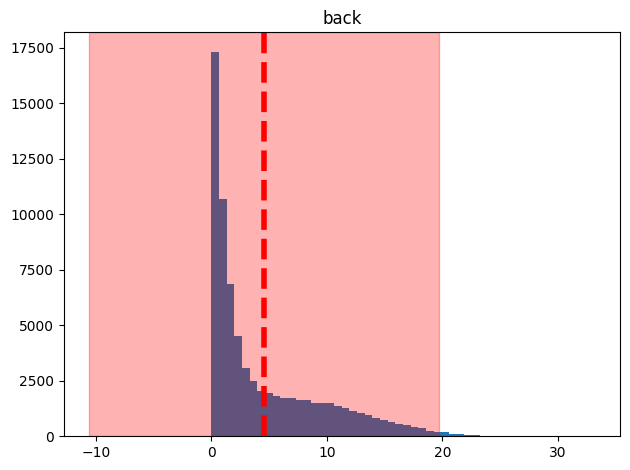

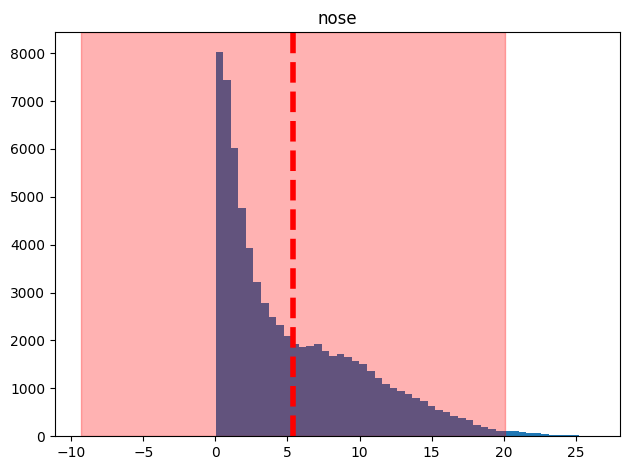

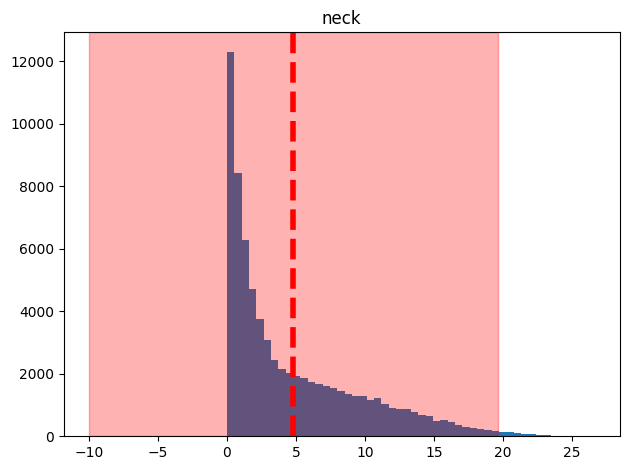

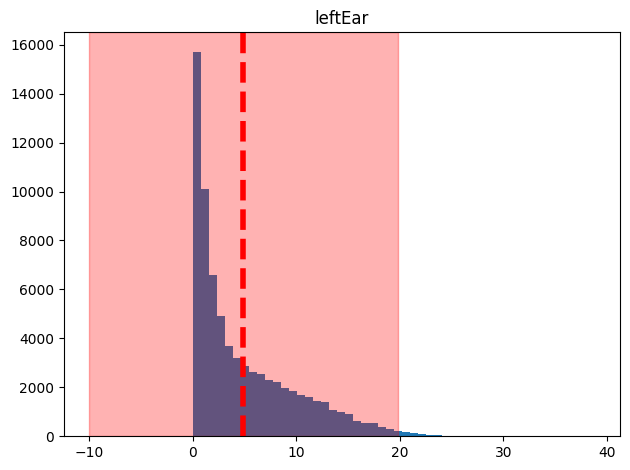

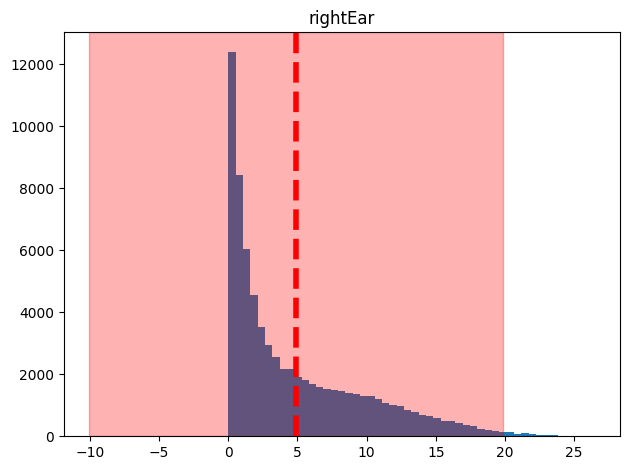

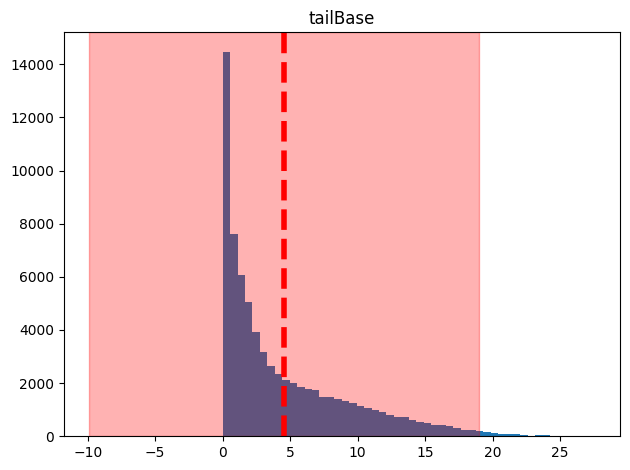

In [16]:
def plot_node_interval_distribution(smoothed_bodypart_data, node):
        body_distances = []
        for t in range(n_timepoint-1):
            node_x, node_y = smoothed_bodypart_data[node]['x'][t], smoothed_bodypart_data[node]['y'][t]
            node_x_next, node_y_next = smoothed_bodypart_data[node]['x'][t+1], smoothed_bodypart_data[node]['y'][t+1]
            distance = np.sqrt((node_x - node_x_next) ** 2 + (node_y - node_y_next) ** 2)
            body_distances.append(distance)
        body_distances = np.array(body_distances)

        plt.hist(body_distances, bins=50)
        plt.axvline(x = np.mean(body_distances), color='r', linestyle='dashed', linewidth=4)
        plt.axvspan(xmin=np.mean(body_distances)-3*np.std(body_distances), xmax=np.mean(body_distances)+3*np.std(body_distances), color='r', alpha=0.3)
        plt.title(f'{node}')
        plt.tight_layout()
        plt.show()

plot_node_interval_distribution(smoothed_bodypart_data, 'back')
plot_node_interval_distribution(smoothed_bodypart_data, 'nose')
plot_node_interval_distribution(smoothed_bodypart_data, 'neck')
plot_node_interval_distribution(smoothed_bodypart_data, 'leftEar')
plot_node_interval_distribution(smoothed_bodypart_data, 'rightEar')
plot_node_interval_distribution(smoothed_bodypart_data, 'tailBase')

In [21]:
def correct_temporal_jumps(bodypart_data, threshold=60.0):
    """
    Correct isolated temporal jumps independently for every node.

    At frame t, if the Euclidean distances from the node's position at t
    to its positions at both t-1 and t+1 exceed `threshold`, replace both
    x[t] and y[t] with the midpoint of the positions at t-1 and t+1.

    Parameters
    ----------
    bodypart_data : dict
        Format:
        {
            "nose": {"x": array, "y": array},
            "back": {"x": array, "y": array},
            ...
        }

    threshold : float
        Temporal jump threshold, normally in pixels.

    Returns
    -------
    corrected_data : dict
        A corrected copy of the input data.

    corrected_frames : dict
        Frame indices corrected for each node.
    """
    corrected_data = {
        node_name: {
            "x": np.asarray(values["x"], dtype=float).copy(),
            "y": np.asarray(values["y"], dtype=float).copy(),
        }
        for node_name, values in bodypart_data.items()
    }

    corrected_frames = {}

    for node_name, node_data in corrected_data.items():
        x = node_data["x"]
        y = node_data["y"]

        if len(x) != len(y):
            raise ValueError(
                f"{node_name!r} has different x and y lengths: "
                f"{len(x)} and {len(y)}"
            )

        if len(x) < 3:
            corrected_frames[node_name] = np.array([], dtype=int)
            continue

        # Preserve the data before this correction round so that one
        # correction does not affect detection or interpolation of another.
        original_x = x.copy()
        original_y = y.copy()

        # For candidate frames t = 1, ..., n_frames - 2.
        distance_from_previous = np.hypot(
            original_x[1:-1] - original_x[:-2],
            original_y[1:-1] - original_y[:-2],
        )

        distance_from_next = np.hypot(
            original_x[1:-1] - original_x[2:],
            original_y[1:-1] - original_y[2:],
        )

        finite_coordinates = (
            np.isfinite(original_x[:-2])
            & np.isfinite(original_y[:-2])
            & np.isfinite(original_x[1:-1])
            & np.isfinite(original_y[1:-1])
            & np.isfinite(original_x[2:])
            & np.isfinite(original_y[2:])
        )

        jump_frames = np.flatnonzero(
            finite_coordinates
            & (distance_from_previous > threshold)
            & (distance_from_next > threshold)
        ) + 1

        # Replace frame t with the midpoint of frames t-1 and t+1.
        x[jump_frames] = (
            original_x[jump_frames - 1]
            + original_x[jump_frames + 1]
        ) / 2.0

        y[jump_frames] = (
            original_y[jump_frames - 1]
            + original_y[jump_frames + 1]
        ) / 2.0

        corrected_frames[node_name] = jump_frames

    return corrected_data, corrected_frames


temporally_corrected_data, temporal_corrected_frames = (
    correct_temporal_jumps(
        smoothed_bodypart_data,
        threshold=25,
    )
)

for node_name, frames in temporal_corrected_frames.items():
    print(f"{node_name}: corrected {len(frames)} temporal jumps")

nose: corrected 14 temporal jumps
leftEar: corrected 32 temporal jumps
rightEar: corrected 15 temporal jumps
scope: corrected 24 temporal jumps
neck: corrected 18 temporal jumps
back: corrected 20 temporal jumps
tailBase: corrected 33 temporal jumps


In [22]:
from pathlib import Path

import cv2
import numpy as np


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
bodyparts = [
    "nose",
    "leftEar",
    "rightEar",
    "neck",
    "back",
    "tailBase",
]

connections = [
    ("nose", "neck"),
    ("leftEar", "rightEar"),
    ("neck", "back"),
    ("back", "tailBase"),
]

# OpenCV uses BGR colors.
# The same body part has the same color in both panels.
point_colors = {
    "nose":     (40, 40, 230),     # red
    "leftEar":  (0, 150, 255),     # orange
    "rightEar": (60, 190, 60),     # green
    "neck":     (230, 120, 30),    # blue
    "back":     (180, 60, 180),    # purple
    "tailBase": (180, 80, 230),    # pink
}

fps = 33.0
panel_width = 1080
panel_height = 1024
header_height = 70

point_radius = 7
line_thickness = 4
link_color = (0, 0, 0)             # black


# ------------------------------------------------------------
# 1. Load original coordinates from bodypart_data
# ------------------------------------------------------------
# Assumes:
# bodypart_data[name]["x"]
# bodypart_data[name]["y"]

original = {}

for name in bodyparts:
    original[name] = {
        "x": np.asarray(bodypart_data[name]["x"]).squeeze(),
        "y": np.asarray(bodypart_data[name]["y"]).squeeze(),
    }


# ------------------------------------------------------------
# 2. Load smoothed coordinates
# ------------------------------------------------------------
smoothed = temporally_corrected_data  # Use the temporally corrected data as the smoothed data.

# Use the common number of frames across original and smoothed data.
n_frames = min(
    min(
        len(original[name]["x"]),
        len(original[name]["y"]),
        len(smoothed[name]["x"]),
        len(smoothed[name]["y"]),
    )
    for name in bodyparts
)

print(f"Number of frames: {n_frames:,}")
print(f"Duration at 33 Hz: {n_frames / fps:.2f} seconds")


# ------------------------------------------------------------
# 3. Initialize side-by-side video
# ------------------------------------------------------------
output_width = panel_width * 2
output_height = panel_height + header_height

output_path = (
    Path(path.data_path)
    / "compare_raw_smoothed_temporal_correction.mp4"
)

writer = cv2.VideoWriter(
    str(output_path),
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (output_width, output_height),
)

if not writer.isOpened():
    raise RuntimeError("Could not initialize the video writer.")


# ------------------------------------------------------------
# Drawing functions
# ------------------------------------------------------------
def draw_centered_text(frame, text, center_x):
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.1
    thickness = 2

    (text_width, text_height), _ = cv2.getTextSize(
        text,
        font,
        font_scale,
        thickness,
    )

    text_x = center_x - text_width // 2
    text_y = (header_height + text_height) // 2

    cv2.putText(
        frame,
        text,
        (text_x, text_y),
        font,
        font_scale,
        (0, 0, 0),
        thickness,
        lineType=cv2.LINE_AA,
    )


def draw_skeleton(frame, coordinates, frame_index, x_offset):
    points = {}

    # Get valid coordinates.
    for name in bodyparts:
        x = coordinates[name]["x"][frame_index]
        y = coordinates[name]["y"][frame_index]

        if not (np.isfinite(x) and np.isfinite(y)):
            continue

        x = int(round(x))
        y = int(round(y))

        # Only draw points inside the original coordinate field.
        if 0 <= x < panel_width and 0 <= y < panel_height:
            points[name] = (
                x + x_offset,
                y + header_height,
            )

    # Draw all links in black.
    for start_name, end_name in connections:
        if start_name in points and end_name in points:
            cv2.line(
                frame,
                points[start_name],
                points[end_name],
                link_color,
                thickness=line_thickness,
                lineType=cv2.LINE_AA,
            )

    # Draw points over the links.
    for name in bodyparts:
        if name not in points:
            continue

        cv2.circle(
            frame,
            points[name],
            point_radius,
            point_colors[name],
            thickness=-1,
            lineType=cv2.LINE_AA,
        )

        # Thin black outline around each point.
        cv2.circle(
            frame,
            points[name],
            point_radius,
            (0, 0, 0),
            thickness=1,
            lineType=cv2.LINE_AA,
        )


# ------------------------------------------------------------
# 4. Render video
# ------------------------------------------------------------
try:
    for frame_index in range(n_frames):
        frame = np.full(
            (output_height, output_width, 3),
            255,
            dtype=np.uint8,
        )

        # Titles
        draw_centered_text(
            frame,
            "original",
            panel_width // 2,
        )

        draw_centered_text(
            frame,
            "smoothed",
            panel_width + panel_width // 2,
        )

        # Panel borders
        cv2.rectangle(
            frame,
            (0, header_height),
            (panel_width - 1, output_height - 1),
            (0, 0, 0),
            thickness=2,
        )

        cv2.rectangle(
            frame,
            (panel_width, header_height),
            (output_width - 1, output_height - 1),
            (0, 0, 0),
            thickness=2,
        )

        # Left panel: original data
        draw_skeleton(
            frame,
            original,
            frame_index,
            x_offset=0,
        )

        # Right panel: smoothed data
        draw_skeleton(
            frame,
            smoothed,
            frame_index,
            x_offset=panel_width,
        )

        writer.write(frame)

        if (frame_index + 1) % 5000 == 0:
            print(
                f"Rendered {frame_index + 1:,} / "
                f"{n_frames:,} frames"
            )

finally:
    writer.release()


print(f"Saved video to:\n{output_path}")

Number of frames: 72,771
Duration at 33 Hz: 2205.18 seconds
Rendered 5,000 / 72,771 frames
Rendered 10,000 / 72,771 frames
Rendered 15,000 / 72,771 frames
Rendered 20,000 / 72,771 frames
Rendered 25,000 / 72,771 frames
Rendered 30,000 / 72,771 frames
Rendered 35,000 / 72,771 frames
Rendered 40,000 / 72,771 frames
Rendered 45,000 / 72,771 frames
Rendered 50,000 / 72,771 frames
Rendered 55,000 / 72,771 frames
Rendered 60,000 / 72,771 frames
Rendered 65,000 / 72,771 frames
Rendered 70,000 / 72,771 frames
Saved video to:
/Users/zimoli/Research/202608_FreelyMoving/Data/compare_raw_smoothed_temporal_correction.mp4


# Correct jumping based on reference node

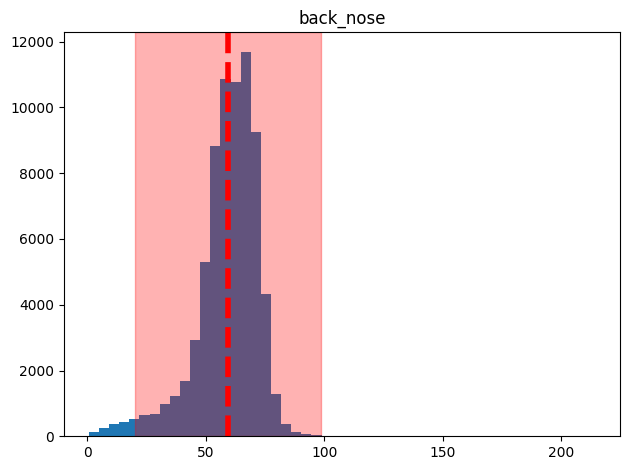

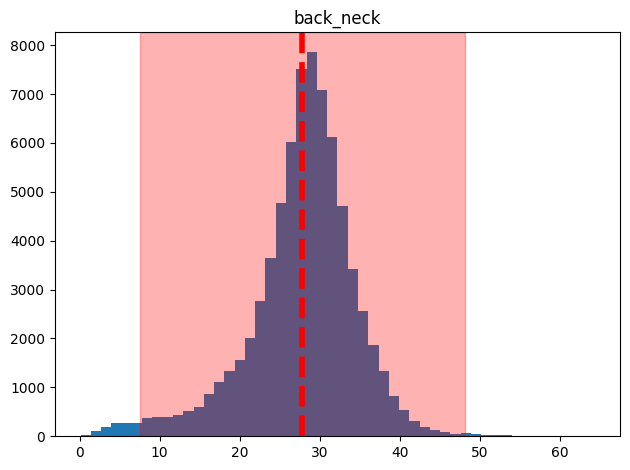

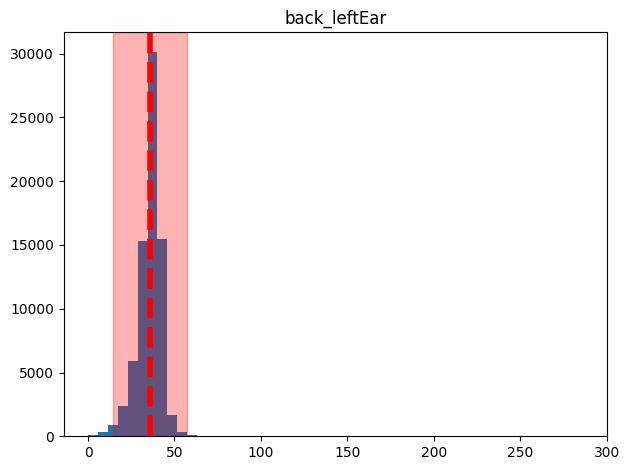

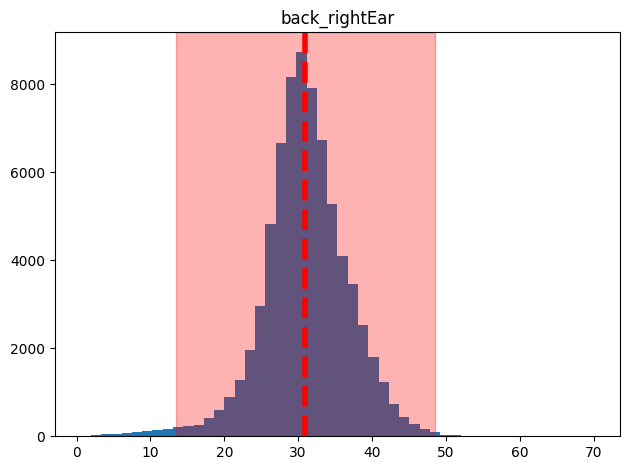

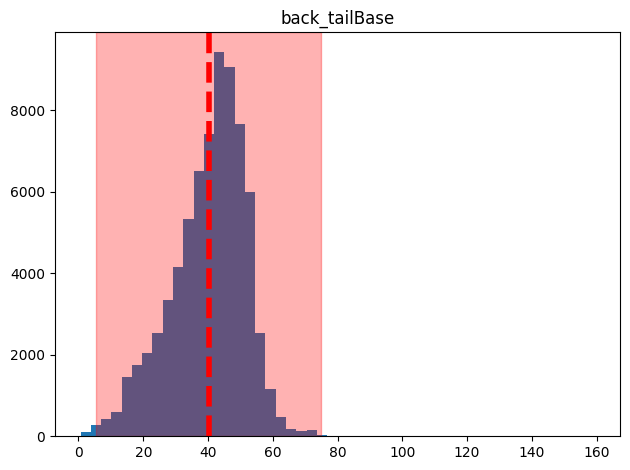

In [9]:
def plot_node_distance_distribution(smoothed_bodypart_data, node1, node2):
        body_distances = []
        for t in range(n_timepoint):
            node1_x, node1_y = smoothed_bodypart_data[node1]['x'][t], smoothed_bodypart_data[node1]['y'][t]
            node2_x, node2_y = smoothed_bodypart_data[node2]['x'][t], smoothed_bodypart_data[node2]['y'][t]
            distance = np.sqrt((node1_x - node2_x) ** 2 + (node1_y - node2_y) ** 2)
            body_distances.append(distance)
        body_distances = np.array(body_distances)

        plt.hist(body_distances, bins=50)
        plt.axvline(x = np.mean(body_distances), color='r', linestyle='dashed', linewidth=4)
        plt.axvspan(xmin=np.mean(body_distances)-3*np.std(body_distances), xmax=np.mean(body_distances)+3*np.std(body_distances), color='r', alpha=0.3)
        plt.title(f'{node1}_{node2}')
        plt.tight_layout()
        plt.show()

plot_node_distance_distribution(smoothed_bodypart_data, 'back', 'nose')
plot_node_distance_distribution(smoothed_bodypart_data, 'back', 'neck')
plot_node_distance_distribution(smoothed_bodypart_data, 'back', 'leftEar')
plot_node_distance_distribution(smoothed_bodypart_data, 'back', 'rightEar')
plot_node_distance_distribution(smoothed_bodypart_data, 'back', 'tailBase')

In [23]:
def correct_distance_outliers(
    bodypart_data,
    reference_node="back",
    node_threshold=60.0,
):
    """
    Correct isolated frames where a node is too far from the reference node.

    If distance(node[t], reference[t]) > threshold, replace node[t] with
    the midpoint of node[t-1] and node[t+1].

    Parameters
    ----------
    bodypart_data : dict
        {
            "nose": {"x": array, "y": array},
            "back": {"x": array, "y": array},
            ...
        }

    reference_node : str
        Node used to calculate the distance threshold.

    node_threshold : float or None
        Maximum allowed node-to-reference distance.

        If None, a separate threshold is calculated for each node as:
            mean(distance) + 2 * std(distance)

    Returns
    -------
    corrected_data : dict
        Copy of the body-part data with outliers corrected.

    corrected_frames : dict
        Corrected frame indices for each node.

    thresholds : dict
        Threshold used for each node.
    """
    if reference_node not in bodypart_data:
        raise KeyError(
            f"Reference node {reference_node!r} is not in bodypart_data"
        )

    corrected_data = {
        node_name: {
            "x": np.asarray(values["x"], dtype=float).copy(),
            "y": np.asarray(values["y"], dtype=float).copy(),
        }
        for node_name, values in bodypart_data.items()
    }

    ref_x = corrected_data[reference_node]["x"]
    ref_y = corrected_data[reference_node]["y"]
    n_frames = len(ref_x)

    corrected_frames = {}
    thresholds = {}

    for node_name, node_data in corrected_data.items():
        if node_name == reference_node:
            continue

        x = node_data["x"]
        y = node_data["y"]

        if len(x) != n_frames or len(y) != n_frames:
            raise ValueError(
                f"{node_name!r} has a different number of frames from "
                f"{reference_node!r}"
            )

        # Distance between this node and the reference node at each frame.
        distances = np.hypot(x - ref_x, y - ref_y)

        # Either use the provided threshold or calculate one for each node.

        node_threshold = (
            np.nanmean(distances)
            + 2 * np.nanstd(distances)
        )


        thresholds[node_name] = node_threshold

        # Identify outliers before modifying any coordinates.
        candidate_frames = np.flatnonzero(distances > node_threshold)

        # The first and last frames cannot be interpolated.
        candidate_frames = candidate_frames[
            (candidate_frames > 0)
            & (candidate_frames < n_frames - 1)
        ]

        node_corrected_frames = []

        for frame in candidate_frames:
            neighboring_coordinates = np.array([
                x[frame - 1],
                y[frame - 1],
                x[frame + 1],
                y[frame + 1],
            ])

            if not np.all(np.isfinite(neighboring_coordinates)):
                continue

            # Only correct isolated outliers. This prevents interpolation
            # using an adjacent frame that is also above the threshold.
            if (
                distances[frame - 1] <= node_threshold
                and distances[frame + 1] <= node_threshold
            ):
                x[frame] = (x[frame - 1] + x[frame + 1]) / 2.0
                y[frame] = (y[frame - 1] + y[frame + 1]) / 2.0

                node_corrected_frames.append(frame)

        corrected_frames[node_name] = np.asarray(
            node_corrected_frames,
            dtype=int,
        )

    return corrected_data, corrected_frames, thresholds

corrected_bodypart_data, corrected_frames, thresholds = (
    correct_distance_outliers(
        temporally_corrected_data,
        reference_node="back",
        node_threshold=60,
    )
)

for node_name, frames in corrected_frames.items():
    print(
        f"{node_name}: corrected {len(frames)} frames; "
        f"threshold = {thresholds[node_name]:.2f}"
    )

nose: corrected 4 frames; threshold = 85.35
leftEar: corrected 5 frames; threshold = 50.11
rightEar: corrected 9 frames; threshold = 42.66
scope: corrected 4 frames; threshold = 63.35
neck: corrected 8 frames; threshold = 41.35
tailBase: corrected 9 frames; threshold = 63.25


# Correct Nose jumping backwards

In [24]:
def correct_nose_position(bodypart_data):
    """
    If nose-to-back distance is smaller than neck-to-back distance at frame t,
    replace the nose position at frame t with its position at frame t-1.

    Frame 0 is not corrected because it has no previous frame.
    """
    required_nodes = {"nose", "neck", "back"}

    missing_nodes = required_nodes - bodypart_data.keys()
    if missing_nodes:
        raise KeyError(f"Missing required nodes: {sorted(missing_nodes)}")

    corrected_data = {
        node_name: {
            "x": np.asarray(values["x"], dtype=float).copy(),
            "y": np.asarray(values["y"], dtype=float).copy(),
        }
        for node_name, values in bodypart_data.items()
    }

    nose_x = corrected_data["nose"]["x"]
    nose_y = corrected_data["nose"]["y"]
    neck_x = corrected_data["neck"]["x"]
    neck_y = corrected_data["neck"]["y"]
    back_x = corrected_data["back"]["x"]
    back_y = corrected_data["back"]["y"]

    n_frames = len(nose_x)

    arrays = {
        "nose y": nose_y,
        "neck x": neck_x,
        "neck y": neck_y,
        "back x": back_x,
        "back y": back_y,
    }

    for array_name, array in arrays.items():
        if len(array) != n_frames:
            raise ValueError(
                f"{array_name} has {len(array)} frames, "
                f"but nose x has {n_frames}"
            )

    corrected_frames = []

    for frame in range(1, n_frames):
        coordinates = np.array([
            nose_x[frame],
            nose_y[frame],
            neck_x[frame],
            neck_y[frame],
            back_x[frame],
            back_y[frame],
            nose_x[frame - 1],
            nose_y[frame - 1],
        ])

        if not np.all(np.isfinite(coordinates)):
            continue

        nose_back_distance = np.hypot(
            nose_x[frame] - back_x[frame],
            nose_y[frame] - back_y[frame],
        )

        neck_back_distance = np.hypot(
            neck_x[frame] - back_x[frame],
            neck_y[frame] - back_y[frame],
        )

        if nose_back_distance < neck_back_distance:
            nose_x[frame] = nose_x[frame - 1]
            nose_y[frame] = nose_y[frame - 1]
            corrected_frames.append(frame)

    return corrected_data, np.asarray(corrected_frames, dtype=int)

final_bodypart_data, nose_corrected_frames = correct_nose_position(
    corrected_bodypart_data
)

print(
    f"Corrected nose position in "
    f"{len(nose_corrected_frames)} frames"
)


Corrected nose position in 2603 frames


In [25]:
# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
bodyparts = [
    "nose",
    "leftEar",
    "rightEar",
    "neck",
    "back",
    "tailBase",
]

connections = [
    ("nose", "neck"),
    ("leftEar", "rightEar"),
    ("neck", "back"),
    ("back", "tailBase"),
]

# OpenCV uses BGR colors.
# The same body part has the same color in both panels.
point_colors = {
    "nose":     (40, 40, 230),     # red
    "leftEar":  (0, 150, 255),     # orange
    "rightEar": (60, 190, 60),     # green
    "neck":     (230, 120, 30),    # blue
    "back":     (180, 60, 180),    # purple
    "tailBase": (180, 80, 230),    # pink
}

fps = 33.0
panel_width = 1080
panel_height = 1024
header_height = 70

point_radius = 7
line_thickness = 4
link_color = (0, 0, 0)             # black


# ------------------------------------------------------------
# 1. Load original coordinates from bodypart_data
# ------------------------------------------------------------
# Assumes:
# bodypart_data[name]["x"]
# bodypart_data[name]["y"]

original = {}

for name in bodyparts:
    original[name] = {
        "x": np.asarray(bodypart_data[name]["x"]).squeeze(),
        "y": np.asarray(bodypart_data[name]["y"]).squeeze(),
    }


# ------------------------------------------------------------
# 2. Load smoothed coordinates
# ------------------------------------------------------------
smoothed = final_bodypart_data  # Use the temporally corrected data as the smoothed data.

# Use the common number of frames across original and smoothed data.
n_frames = min(
    min(
        len(original[name]["x"]),
        len(original[name]["y"]),
        len(smoothed[name]["x"]),
        len(smoothed[name]["y"]),
    )
    for name in bodyparts
)

print(f"Number of frames: {n_frames:,}")
print(f"Duration at 33 Hz: {n_frames / fps:.2f} seconds")


# ------------------------------------------------------------
# 3. Initialize side-by-side video
# ------------------------------------------------------------
output_width = panel_width * 2
output_height = panel_height + header_height

output_path = (
    Path(path.data_path)
    / "compare_raw_smoothed_nose_correction.mp4"
)

writer = cv2.VideoWriter(
    str(output_path),
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (output_width, output_height),
)

if not writer.isOpened():
    raise RuntimeError("Could not initialize the video writer.")


# ------------------------------------------------------------
# Drawing functions
# ------------------------------------------------------------
def draw_centered_text(frame, text, center_x):
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.1
    thickness = 2

    (text_width, text_height), _ = cv2.getTextSize(
        text,
        font,
        font_scale,
        thickness,
    )

    text_x = center_x - text_width // 2
    text_y = (header_height + text_height) // 2

    cv2.putText(
        frame,
        text,
        (text_x, text_y),
        font,
        font_scale,
        (0, 0, 0),
        thickness,
        lineType=cv2.LINE_AA,
    )


def draw_skeleton(frame, coordinates, frame_index, x_offset):
    points = {}

    # Get valid coordinates.
    for name in bodyparts:
        x = coordinates[name]["x"][frame_index]
        y = coordinates[name]["y"][frame_index]

        if not (np.isfinite(x) and np.isfinite(y)):
            continue

        x = int(round(x))
        y = int(round(y))

        # Only draw points inside the original coordinate field.
        if 0 <= x < panel_width and 0 <= y < panel_height:
            points[name] = (
                x + x_offset,
                y + header_height,
            )

    # Draw all links in black.
    for start_name, end_name in connections:
        if start_name in points and end_name in points:
            cv2.line(
                frame,
                points[start_name],
                points[end_name],
                link_color,
                thickness=line_thickness,
                lineType=cv2.LINE_AA,
            )

    # Draw points over the links.
    for name in bodyparts:
        if name not in points:
            continue

        cv2.circle(
            frame,
            points[name],
            point_radius,
            point_colors[name],
            thickness=-1,
            lineType=cv2.LINE_AA,
        )

        # Thin black outline around each point.
        cv2.circle(
            frame,
            points[name],
            point_radius,
            (0, 0, 0),
            thickness=1,
            lineType=cv2.LINE_AA,
        )


# ------------------------------------------------------------
# 4. Render video
# ------------------------------------------------------------
try:
    for frame_index in range(n_frames):
        frame = np.full(
            (output_height, output_width, 3),
            255,
            dtype=np.uint8,
        )

        # Titles
        draw_centered_text(
            frame,
            "original",
            panel_width // 2,
        )

        draw_centered_text(
            frame,
            "smoothed",
            panel_width + panel_width // 2,
        )

        # Panel borders
        cv2.rectangle(
            frame,
            (0, header_height),
            (panel_width - 1, output_height - 1),
            (0, 0, 0),
            thickness=2,
        )

        cv2.rectangle(
            frame,
            (panel_width, header_height),
            (output_width - 1, output_height - 1),
            (0, 0, 0),
            thickness=2,
        )

        # Left panel: original data
        draw_skeleton(
            frame,
            original,
            frame_index,
            x_offset=0,
        )

        # Right panel: smoothed data
        draw_skeleton(
            frame,
            smoothed,
            frame_index,
            x_offset=panel_width,
        )

        writer.write(frame)

        if (frame_index + 1) % 5000 == 0:
            print(
                f"Rendered {frame_index + 1:,} / "
                f"{n_frames:,} frames"
            )

finally:
    writer.release()


print(f"Saved video to:\n{output_path}")

Number of frames: 72,771
Duration at 33 Hz: 2205.18 seconds
Rendered 5,000 / 72,771 frames
Rendered 10,000 / 72,771 frames
Rendered 15,000 / 72,771 frames
Rendered 20,000 / 72,771 frames
Rendered 25,000 / 72,771 frames
Rendered 30,000 / 72,771 frames
Rendered 35,000 / 72,771 frames
Rendered 40,000 / 72,771 frames
Rendered 45,000 / 72,771 frames
Rendered 50,000 / 72,771 frames
Rendered 55,000 / 72,771 frames
Rendered 60,000 / 72,771 frames
Rendered 65,000 / 72,771 frames
Rendered 70,000 / 72,771 frames
Saved video to:
/Users/zimoli/Research/202608_FreelyMoving/Data/compare_raw_smoothed_nose_correction.mp4


# turn it back to .h5 file

In [28]:
def corrected_data_to_dlc_h5(
    corrected_data,
    original_h5_path,
    output_h5_path,
):
    """
    Insert corrected body-part coordinates into an existing DLC dataframe
    and save it as a DLC-compatible HDF5 file.

    Parameters
    ----------
    corrected_data : dict
        {
            "nose": {"x": array, "y": array},
            "neck": {"x": array, "y": array},
            ...
        }

    original_h5_path : str or Path
        Original DeepLabCut .h5 file used as a template.

    output_h5_path : str or Path
        Path for the corrected .h5 file.

    Returns
    -------
    corrected_df : pandas.DataFrame
        The corrected DLC dataframe.
    """
    original_h5_path = Path(original_h5_path)
    output_h5_path = Path(output_h5_path)

    # Load the original DLC dataframe.
    corrected_df = pd.read_hdf(original_h5_path).copy()

    if not isinstance(corrected_df.columns, pd.MultiIndex):
        raise ValueError(
            "The original H5 file does not have DLC-style MultiIndex columns."
        )

    column_names = list(corrected_df.columns.names)

    try:
        bodypart_level = column_names.index("bodyparts")
        coordinate_level = column_names.index("coords")
    except ValueError:
        # Standard single-animal DLC format:
        # scorer -> bodyparts -> coords
        if corrected_df.columns.nlevels == 3:
            bodypart_level = 1
            coordinate_level = 2
        else:
            raise ValueError(
                "Could not identify the bodypart and coordinate column levels. "
                f"Column levels are: {column_names}"
            )

    n_frames = len(corrected_df)

    available_bodyparts = set(
        corrected_df.columns.get_level_values(bodypart_level)
    )

    for node_name, node_data in corrected_data.items():
        if node_name not in available_bodyparts:
            print(
                f"Warning: {node_name!r} is not present in the original "
                "DLC file and was skipped."
            )
            continue

        x = np.asarray(node_data["x"], dtype=float)
        y = np.asarray(node_data["y"], dtype=float)

        if len(x) != n_frames or len(y) != n_frames:
            raise ValueError(
                f"{node_name!r} has {len(x)} x-values and {len(y)} y-values, "
                f"but the DLC file has {n_frames} frames."
            )

        # Find the full MultiIndex columns corresponding to this node's x and y.
        x_columns = [
            column
            for column in corrected_df.columns
            if (
                column[bodypart_level] == node_name
                and column[coordinate_level] == "x"
            )
        ]

        y_columns = [
            column
            for column in corrected_df.columns
            if (
                column[bodypart_level] == node_name
                and column[coordinate_level] == "y"
            )
        ]

        if not x_columns or not y_columns:
            raise KeyError(
                f"Could not find x/y columns for body part {node_name!r}"
            )

        # Usually there is one x column and one y column per body part.
        for column in x_columns:
            corrected_df.loc[:, column] = x

        for column in y_columns:
            corrected_df.loc[:, column] = y

        # Likelihood is intentionally preserved from the original file.

    output_h5_path.parent.mkdir(parents=True, exist_ok=True)

    corrected_df.to_hdf(
        output_h5_path,
        key="df_with_missing",
        mode="w",
        format="table",
    )

    print(f"Saved corrected DLC file to: {output_h5_path}")

    return corrected_df


original_h5 = (
    f"{path.data_path}/ribo8s002_20260804_0001DLC_resnet50_stickerNoseScopeAug4shuffle1_100000.h5"
)


output_h5 = (
    f"{path.data_path}/smoothed_corrected_raw.h5"
)

corrected_dlc_df = corrected_data_to_dlc_h5(
    corrected_data=final_bodypart_data,
    original_h5_path=original_h5,
    output_h5_path=output_h5,
)

Saved corrected DLC file to: /Users/zimoli/Research/202608_FreelyMoving/Data/smoothed_corrected_raw.h5
